# Patch Dataset Viewer

Total image counts per repo, and 5 random patches shown across all 4 image types.

In [7]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

SAT_OUT    = "/Volumes/Spleen/CABIN/datasets/patches/satellite_imagery"
DEM_OUT    = "/Volumes/Spleen/CABIN/datasets/patches/elevation"
CANOPY_OUT = "/Volumes/Spleen/CABIN/datasets/patches/crown_closure"
MASK_OUT   = "/Volumes/Spleen/CABIN/datasets/patches/crown_closure_mask"

REPOS = {
    "Satellite": SAT_OUT,
    "Elevation": DEM_OUT,
    "Crown Closure Mask": MASK_OUT,
    "Crown Closure": CANOPY_OUT,
}

In [8]:
counts = {
    name: len([f for f in os.listdir(path) if f.startswith("patch_") and f.endswith(".png")])
    for name, path in REPOS.items()
}

for name, count in counts.items():
    print(f"{name:20s}: {count} images")

print(f"\nTotal images across all 4 repos: {sum(counts.values())}")

Satellite           : 5616 images
Elevation           : 5616 images
Crown Closure Mask  : 5616 images
Crown Closure       : 5616 images

Total images across all 4 repos: 22464


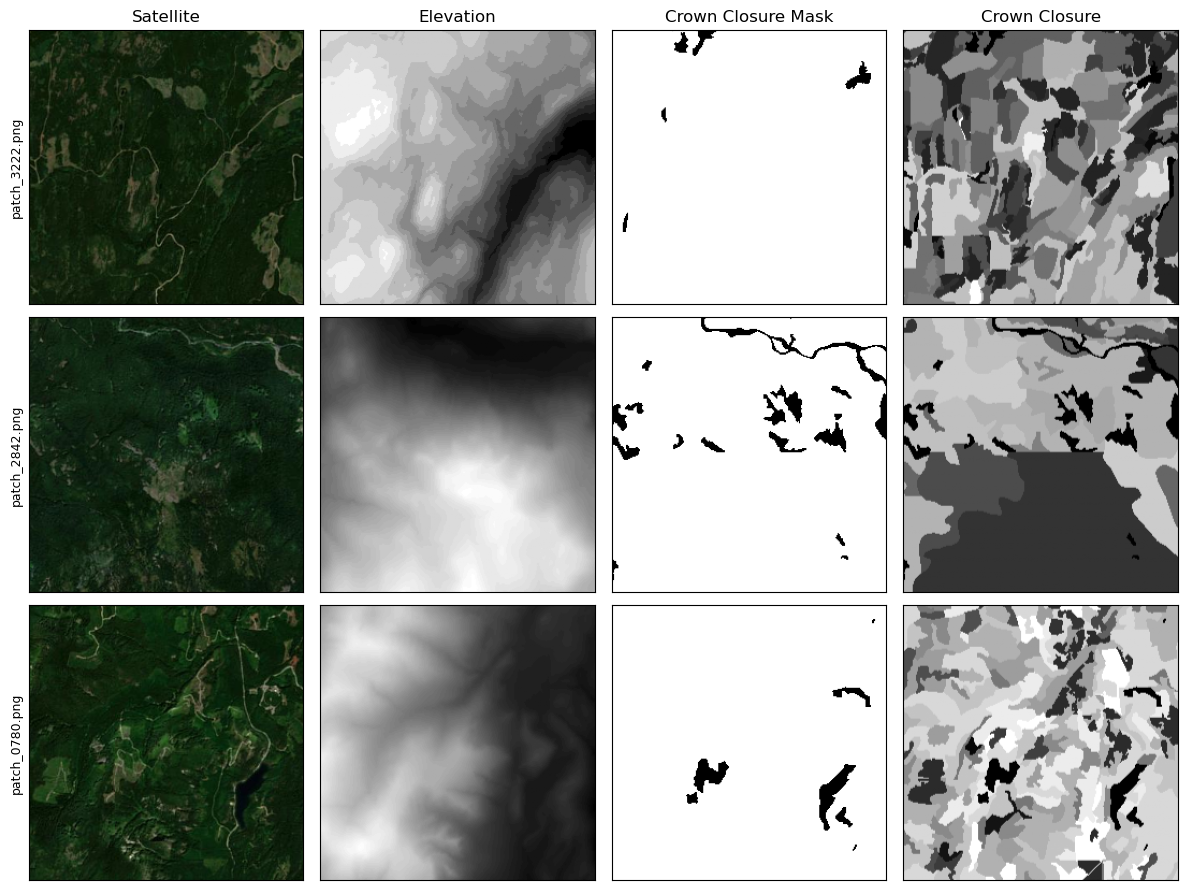

In [14]:
sat_files = sorted(f for f in os.listdir(SAT_OUT) if f.startswith("patch_") and f.endswith(".png"))
sample = random.sample(sat_files, 3)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row, filename in enumerate(sample):
    for col, (name, path) in enumerate(REPOS.items()):
        img_path = os.path.join(path, filename)
        ax = axes[row, col]
        if os.path.exists(img_path):
            ax.imshow(Image.open(img_path), cmap="gray")
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(name)
        if col == 0:
            ax.set_ylabel(filename, fontsize=9)

plt.tight_layout()
plt.show()